In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

In [2]:
df = pd.read_csv("dataset2.csv")

print(df.head())
print(df.info())

    AGE          BP  CHOLESTROL gender        bmi family_history  \
0  56.0   98.461619         NaN      F  28.583459             no   
1  69.0   95.567979  118.510149      F  30.755321            NaN   
2  46.0  117.906200  374.018997      M  23.903592             no   
3  32.0  120.252654  211.928191      M  30.127559             no   
4  60.0  109.285294  149.291120      M  27.442521             no   

  smoking_status alcohol_consumption physical_activity  stress_level  \
0     non-smoker                  no              high           8.0   
1         smoker                 yes              high           1.5   
2         smoker                  no            medium           9.0   
3     non-smoker                  no              high           1.0   
4         smoker                  no            medium          10.0   

   sleep_hours diabetes hypertension  
0     9.086921      yes           no  
1     8.510910       no           no  
2     0.813842       no           no  
3 

In [3]:
df = df.loc[:, df.notna().any()]
for col in df.columns:
    if df[col].isnull().sum() > 0:
        if df[col].dropna().shape[0] > 0:
            df[col] = df[col].fillna(df[col].mode()[0])




In [4]:
cols = ["bmi", "sleep_hours", "BP", "CHOLESTROL"]

for col in cols:
    if col in df.columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        df[col] = df[col].clip(lower, upper)

In [5]:
if "bmi" in df.columns:
    df["bmi"] = df["bmi"].round(1)

if "sleep_hours" in df.columns:
    df["sleep_hours"] = df["sleep_hours"].round(1)

if "BP" in df.columns:
    df["BP"] = df["BP"].round(0)

if "CHOLESTROL" in df.columns:
    df["CHOLESTROL"] = df["CHOLESTROL"].round(0)


In [6]:
print("Remaining nulls:")
print(df.isnull().sum())

print("\nDataset shape:", df.shape)

Remaining nulls:
AGE                    0
BP                     0
CHOLESTROL             0
gender                 0
bmi                    0
family_history         0
smoking_status         0
alcohol_consumption    0
physical_activity      0
stress_level           0
sleep_hours            0
diabetes               0
hypertension           0
dtype: int64

Dataset shape: (200000, 13)


In [7]:
import matplotlib.pyplot as plt

def plot_pie(column_name):
    counts = df[column_name].value_counts()
    
    plt.figure(figsize=(6,6))
    plt.pie(counts, labels=counts.index, autopct='%1.1f%%')
    plt.title(f"{column_name} Distribution")
    plt.show()

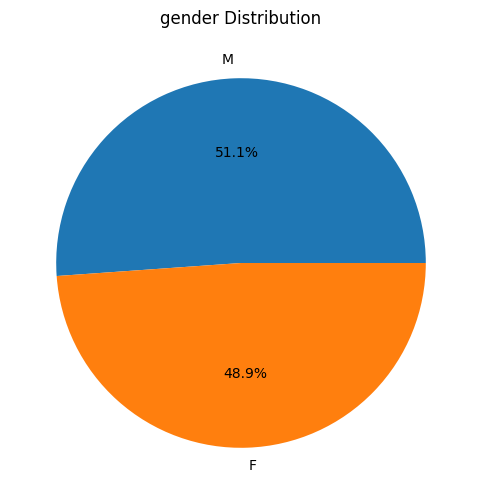

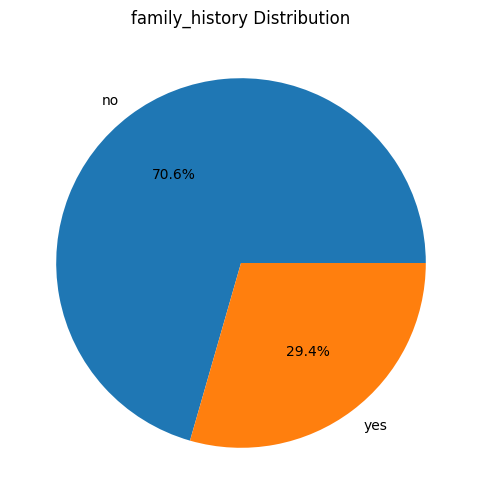

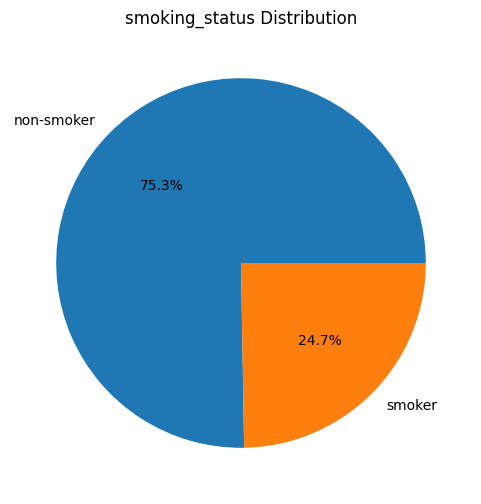

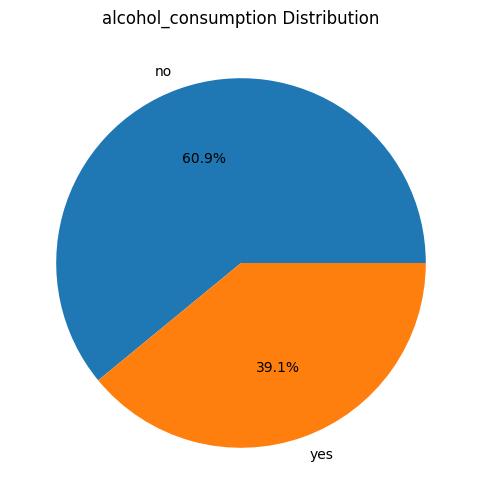

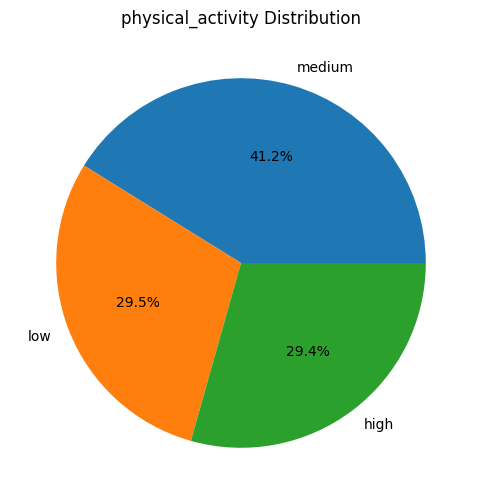

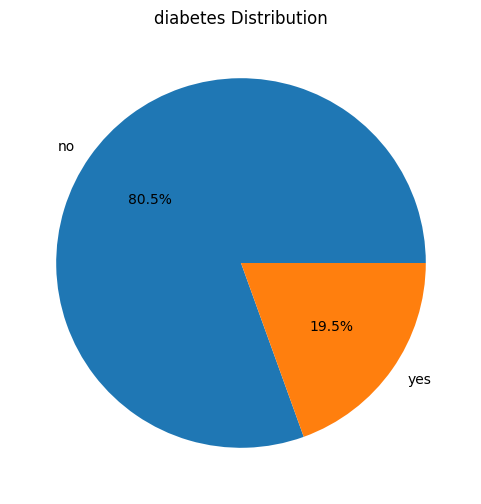

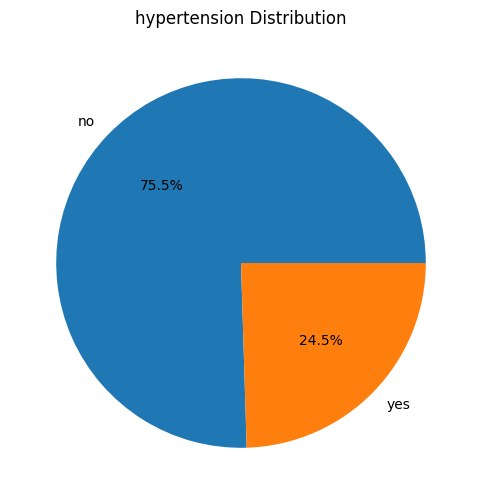

In [8]:
plot_pie("gender")
plot_pie("family_history")
plot_pie("smoking_status")
plot_pie("alcohol_consumption")
plot_pie("physical_activity")
plot_pie("diabetes")
plot_pie("hypertension")

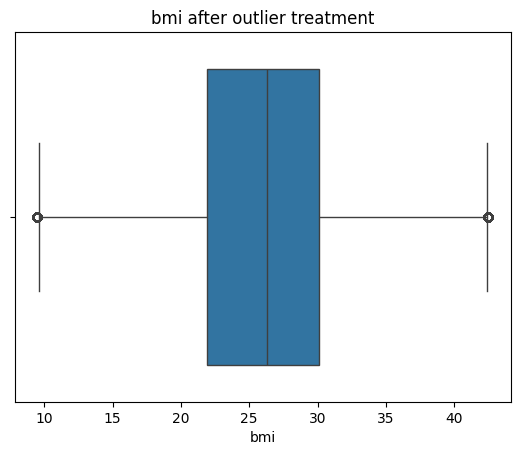

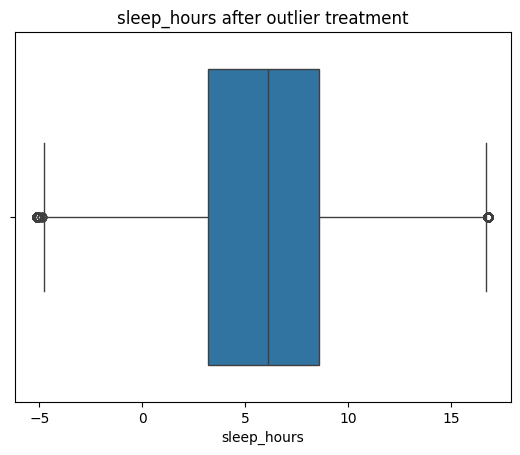

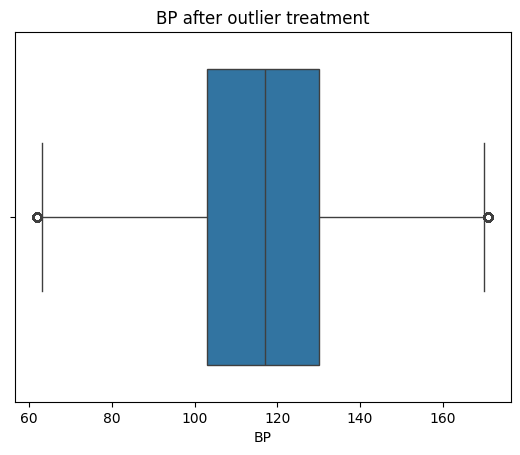

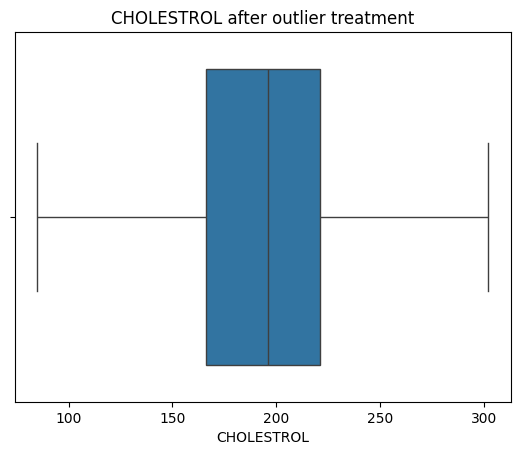

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

cols = ["bmi", "sleep_hours", "BP", "CHOLESTROL"]

for col in cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f"{col} after outlier treatment")
    plt.show()

In [10]:
df["heart_risk"] = (
    (df["BP"] > 140) |
    (df["CHOLESTROL"] > 240) |
    (df["bmi"] > 30) |
    (df["smoking_status"] == 1)
).astype(int)

X = df.drop("heart_risk", axis=1)
y = df["heart_risk"]
X = pd.get_dummies(X, drop_first=True)